# Árbol de regresión para consumo eléctrico

## Objetivos de aprendizaje

Al finalizar este laboratorio podrás:

- explicar cómo un árbol de regresión divide el espacio de predictores;
- comparar la profundidad, el tamaño de hoja y el error en una serie horaria;
- seleccionar hiperparámetros con `TimeSeriesSplit` y mantener un test cronológico reservado;
- comparar el árbol con un `DummyRegressor` y leer sus importancias con cautela.

## Problema y datos

El target es `Consumption` en registros horarios del CSV eléctrico. Las variables incluyen producción energética y atributos de calendario derivados de la fecha. Se utiliza `Production` contemporánea, por lo que el ejercicio estima consumo condicionado a esa medición; no representa un pronóstico futuro si producción no se conoce para el horizonte.

Las filas se ordenan cronológicamente y se separan 70/15/15 en train, validation y test. El árbol no requiere escalado: sus divisiones dependen de umbrales por variable. La complejidad se selecciona mediante CV temporal dentro de train; test queda reservado.

In [ ]:
# Modelo de arbol, baseline trivial y metricas
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from ml_course.data import get_data_path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Construimos una ruta reproducible al archivo fuente compartido
from ml_course.data import get_data_path

csv_path = get_data_path("electricity_consumption_and_production.csv", category="external")
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [ ]:
# Variables energeticas candidatas; el analisis de correlacion se hara solo en train.
candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass',
]
print('Variables energeticas candidatas:', candidate_cols)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


In [ ]:
# Funcion para generar variables temporales a partir del indice de fechas
def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour'] = out.index.hour
    out['day_of_week'] = out.index.day_of_week
    out['month'] = out.index.month
    out['quarter'] = out.index.quarter
    out['year'] = out.index.year
    out['day_of_year'] = out.index.dayofyear
    return out

feat_df = create_time_features(raw)
energy_candidate_features = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass',
]
categorical_time_features = ['hour', 'day_of_week', 'month', 'quarter', 'year']
numeric_features = energy_candidate_features + ['day_of_year']
TARGET = 'Consumption'

# Conservamos categorias hasta el split; el encoder se ajustara con train.
model_df = feat_df[['Consumption'] + numeric_features + categorical_time_features].copy()
print('Ingenieria temporal completada; categorias pendientes de codificacion train-only.')
print('Observaciones y features preliminares:', model_df.shape)
print('Variables categoricas de calendario:', categorical_time_features)

Ingenieria completada.
Total de features para el modelo: 59
Primeras 10 features: ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'day_of_year', 'hour_1']


In [ ]:
# Particion temporal cronologica: train 70%, validation 15%, test 15%.
model_df = model_df.sort_index()
n_rows = len(model_df)
train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:validation_end].copy()
test_df = model_df.iloc[validation_end:].copy()

corr_with_target = train_df[['Consumption'] + candidate_cols].corr(numeric_only=True)['Consumption']
corr_with_target = corr_with_target.drop('Consumption').sort_values(key=np.abs, ascending=False)
display(corr_with_target.to_frame('corr_vs_consumption_train'))

# El encoder se ajusta solo en train; categorias futuras se ignoran.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoder.fit(train_df[categorical_time_features])
encoded_columns = encoder.get_feature_names_out(categorical_time_features)

def encode_calendar_features(partition):
    encoded = encoder.transform(partition[categorical_time_features])
    encoded_frame = pd.DataFrame(encoded, columns=encoded_columns, index=partition.index)
    return pd.concat([partition.drop(columns=categorical_time_features), encoded_frame], axis=1)

train_df = encode_calendar_features(train_df)
val_df = encode_calendar_features(val_df)
test_df = encode_calendar_features(test_df)
FEATURES = [column for column in train_df.columns if column != TARGET]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]
model_df = pd.concat([train_df, val_df, test_df]).sort_index()

print('Train:', train_df.index.min(), '->', train_df.index.max(), X_train.shape)
print('Validation:', val_df.index.min(), '->', val_df.index.max(), X_val.shape)
print('Test:', test_df.index.min(), '->', test_df.index.max(), X_test.shape)
print('No se aplica escalado: el arbol divide por umbrales de feature.')

Train size: (43967, 59)
Validation size: (9421, 59)
Test size: (9422, 59)
Random state usado: 42
Escalado aplicado: no, porque el modelo es un arbol de regresion.


In [ ]:
# Entrenamos el baseline y el arbol con las features ingenierizadas.
dummy_model = DummyRegressor(strategy='mean').fit(X_train, y_train)
regression_tree = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
).fit(X_train, y_train)

predictions = {
    'DummyRegressor (media)': (dummy_model.predict(X_val), dummy_model.predict(X_test)),
    'DecisionTreeRegressor': (regression_tree.predict(X_val), regression_tree.predict(X_test)),
}
pred_val, pred_tree = predictions['DecisionTreeRegressor']

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    if not np.any(nonzero):
        return float('nan')
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

results = pd.DataFrame([
    {
        'split': split_name,
        'modelo': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAPE_%': mape(y_true, y_pred),
    }
    for split_name, y_true, prediction_index in [
        ('validation', y_val, 0),
        ('test', y_test, 1),
    ]
    for model_name, model_prediction in predictions.items()
    for y_pred in [model_prediction[prediction_index]]
]).set_index(['split', 'modelo'])

feature_importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': regression_tree.feature_importances_,
}).sort_values('importance', ascending=False)

print('Parametros y complejidad del arbol:')
print({
    'max_depth': regression_tree.max_depth,
    'min_samples_leaf': regression_tree.min_samples_leaf,
    'n_leaves': regression_tree.get_n_leaves(),
    'n_nodes': regression_tree.tree_.node_count,
})
print('Metricas de baseline y arbol:')
display(results.round(4))
print('Top 12 features por importancia:')
display(feature_importance_df.head(12))

Parametros del arbol:
{'max_depth': 12, 'min_samples_leaf': 5, 'n_leaves': np.int64(1742), 'n_nodes': 3483}
Top 12 features por importancia:


,feature,importance
0,Production,0.559994
2,Wind,0.079031
5,Coal,0.053866
4,Oil and Gas,0.048894
6,Solar,0.038733
3,Hydroelectric,0.024955
37,day_of_week_6,0.023391
8,day_of_year,0.021917
49,quarter_2,0.021489
7,Biomass,0.019697


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,DecisionTreeRegressor,372.4800,496.1195,0.7818,5.9048
test,DecisionTreeRegressor,367.2036,487.3229,0.7916,5.8291


Resumen de error en test:
       error_tree  abs_error
count    9422.000   9422.000
mean       -6.726    367.253
std       487.379    320.461
min     -2434.196      0.021
25%      -278.928    127.907
50%        -6.471    279.184
75%       279.970    522.562
max      2456.347   2456.347


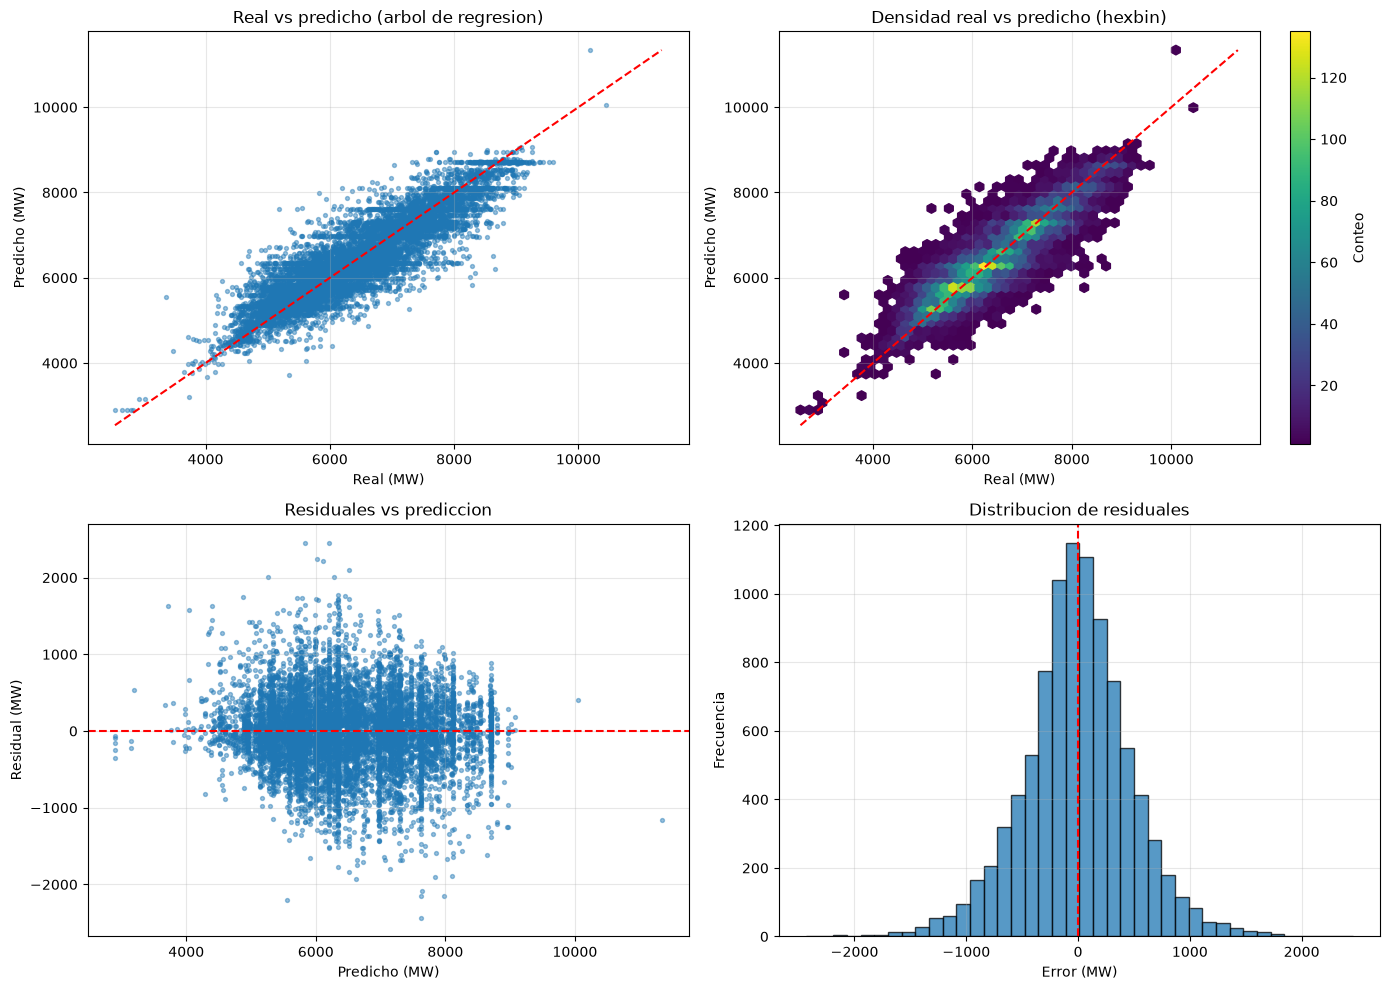

In [8]:
# Analisis de predicciones para split aleatorio (sin orden temporal)
pred_df = pd.DataFrame(index=y_test.index)
pred_df['Consumption'] = y_test
pred_df['pred_tree'] = pred_tree
pred_df['error_tree'] = pred_df['Consumption'] - pred_df['pred_tree']
pred_df['abs_error'] = pred_df['error_tree'].abs()

print('Resumen de error en test:')
print(pred_df[['error_tree', 'abs_error']].describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Parity plot: real vs predicho
axes[0, 0].scatter(pred_df['Consumption'], pred_df['pred_tree'], s=8, alpha=0.45)
min_v = min(pred_df['Consumption'].min(), pred_df['pred_tree'].min())
max_v = max(pred_df['Consumption'].max(), pred_df['pred_tree'].max())
axes[0, 0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 0].set_title('Real vs predicho (arbol de regresion)')
axes[0, 0].set_xlabel('Real (MW)')
axes[0, 0].set_ylabel('Predicho (MW)')
axes[0, 0].grid(alpha=0.3)

# 2) Hexbin para densidad de puntos
hb = axes[0, 1].hexbin(
    pred_df['Consumption'],
    pred_df['pred_tree'],
    gridsize=45,
    cmap='viridis',
    mincnt=1
)
axes[0, 1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 1].set_title('Densidad real vs predicho (hexbin)')
axes[0, 1].set_xlabel('Real (MW)')
axes[0, 1].set_ylabel('Predicho (MW)')
axes[0, 1].grid(alpha=0.3)
fig.colorbar(hb, ax=axes[0, 1], label='Conteo')

# 3) Residuales vs prediccion
axes[1, 0].scatter(pred_df['pred_tree'], pred_df['error_tree'], s=8, alpha=0.45)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('Predicho (MW)')
axes[1, 0].set_ylabel('Residual (MW)')
axes[1, 0].grid(alpha=0.3)

# 4) Histograma de residuales
axes[1, 1].hist(pred_df['error_tree'], bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('Distribucion de residuales')
axes[1, 1].set_xlabel('Error (MW)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretación de la regresión con árbol

Compara las métricas de `DecisionTreeRegressor` con el baseline de media en validation y test. Un árbol puede capturar umbrales e interacciones, pero una profundidad alta o hojas pequeñas pueden ajustar fluctuaciones particulares del entrenamiento. Revisa la complejidad reportada y la estabilidad de los errores en el periodo test.

Las divisiones y la importancia por reducción de impurity describen cómo se construyó este árbol; no miden causalidad ni garantizan que la importancia se mantenga en otros periodos.

## Ajuste y analisis del arbol de regresion

En esta seccion se realizan tres tareas:
1. Seleccion de hiperparametros mediante validacion cruzada.
2. Analisis de importancia de features del arbol ajustado.
3. Visualizacion grafica de una version podada del arbol.

In [ ]:
# Validacion cruzada temporal para seleccionar hiperparametros del arbol.
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

cv_tree = TimeSeriesSplit(n_splits=5)
param_grid_tree = {
    'max_depth': [6, 9, 12, 15, None],
    'min_samples_leaf': [2, 5, 10, 20],
    'min_samples_split': [2, 10, 20],
}

tree_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_tree,
    scoring='neg_root_mean_squared_error',
    cv=cv_tree,
    n_jobs=-1,
    refit=True,
)
tree_search.fit(X_train, y_train)

best_tree_params = tree_search.best_params_
best_tree_model = tree_search.best_estimator_
pred_val_tree_cv = best_tree_model.predict(X_val)
pred_test_tree_cv = best_tree_model.predict(X_test)

tree_cv_results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': 'DecisionTreeRegressor (TimeSeriesSplit)',
        'MAE': mean_absolute_error(y_val, pred_val_tree_cv),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_tree_cv)),
        'R2': r2_score(y_val, pred_val_tree_cv),
        'MAPE_%': mape(y_val, pred_val_tree_cv),
    },
    {
        'split': 'test',
        'modelo': 'DecisionTreeRegressor (TimeSeriesSplit)',
        'MAE': mean_absolute_error(y_test, pred_test_tree_cv),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_tree_cv)),
        'R2': r2_score(y_test, pred_test_tree_cv),
        'MAPE_%': mape(y_test, pred_test_tree_cv),
    },
]).set_index(['split', 'modelo'])

cv_results_tree_df = pd.DataFrame(tree_search.cv_results_).sort_values(
    'rank_test_score'
).head(10)

print('Mejores hiperparametros encontrados con TimeSeriesSplit:')
print(best_tree_params)
print('\nMetricas en validation y test:')
display(tree_cv_results.round(4))
print('\nTop 10 configuraciones por RMSE promedio en CV:')
display(
    cv_results_tree_df[
        ['param_max_depth', 'param_min_samples_leaf', 'param_min_samples_split',
         'mean_test_score', 'std_test_score', 'rank_test_score']
    ].assign(mean_RMSE=lambda df: -df['mean_test_score'])
    .drop(columns='mean_test_score')
    .round(4)
)

Mejores hiperparametros encontrados:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 20}

Metricas del arbol ajustado por validacion cruzada:


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,DecisionTreeRegressor (CV),315.4104,445.3392,0.8242,4.9900
test,DecisionTreeRegressor (CV),311.8271,435.7359,0.8334,4.9333



Top 10 configuraciones por RMSE promedio en CV:


,param_max_depth,param_min_samples_leaf,param_min_samples_split,std_test_score,rank_test_score,mean_RMSE
50,None,2,20,7.5920,1,455.5804
49,None,2,10,8.5435,2,459.3036
53,None,5,20,5.1453,3,461.5521
51,None,5,2,5.3870,4,463.1021
52,None,5,10,5.3870,4,463.1021
48,None,2,2,7.6402,6,470.2164
54,None,10,2,6.2222,7,471.1493
55,None,10,10,6.2222,7,471.1493
56,None,10,20,6.2222,7,471.1493
38,15,2,20,7.7082,10,472.9859


### Importancia de features del arbol ajustado

La importancia de cada feature se calcula a partir de la reduccion total de impureza aportada por los nodos que utilizan esa variable. Valores mayores indican mayor contribucion al ajuste del arbol, pero no implican causalidad.

Features mas importantes del arbol ajustado:


,feature,importance
0,Production,0.507387
2,Wind,0.075279
5,Coal,0.056749
4,Oil and Gas,0.052107
6,Solar,0.038173
8,day_of_year,0.033280
3,Hydroelectric,0.029242
7,Biomass,0.024027
37,day_of_week_6,0.022288
1,Nuclear,0.021743


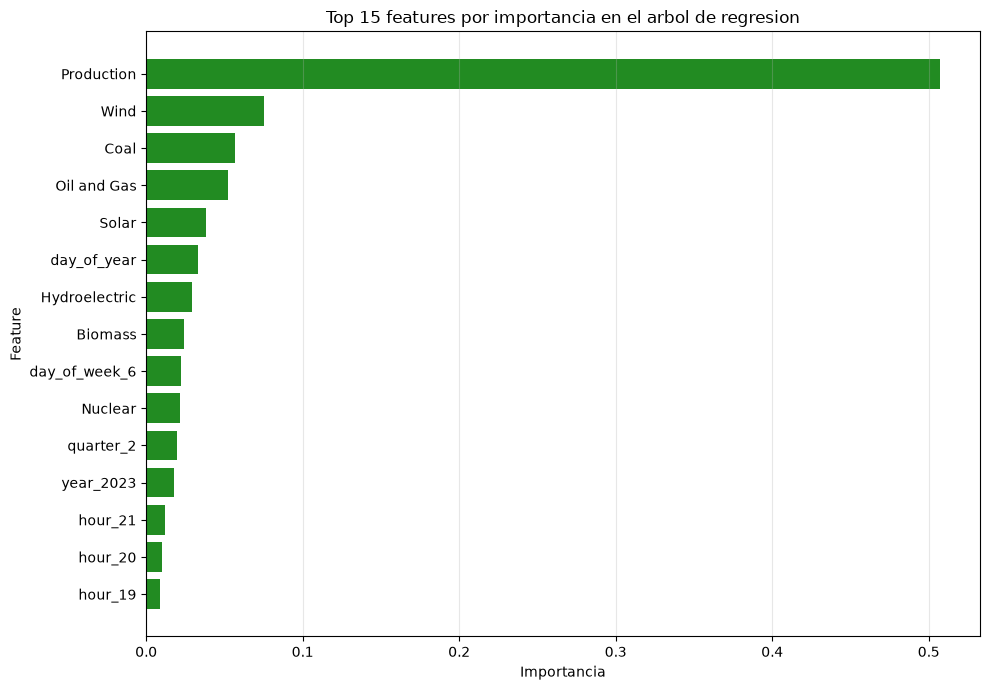

In [24]:
# Tabla y grafico de importancia de features del mejor arbol
feature_importance_cv_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': best_tree_model.feature_importances_,
}).sort_values('importance', ascending=False)

print('Features mas importantes del arbol ajustado:')
display(feature_importance_cv_df.head(15).round(6))

importance_plot_df = feature_importance_cv_df.head(15).sort_values('importance')
plt.figure(figsize=(10, 7))
plt.barh(importance_plot_df['feature'], importance_plot_df['importance'], color='forestgreen')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.title('Top 15 features por importancia en el arbol de regresion')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Grafico del arbol de regresion

Se visualiza una version limitada a los primeros niveles para conservar legibilidad. El modelo completo sigue siendo `best_tree_model`.

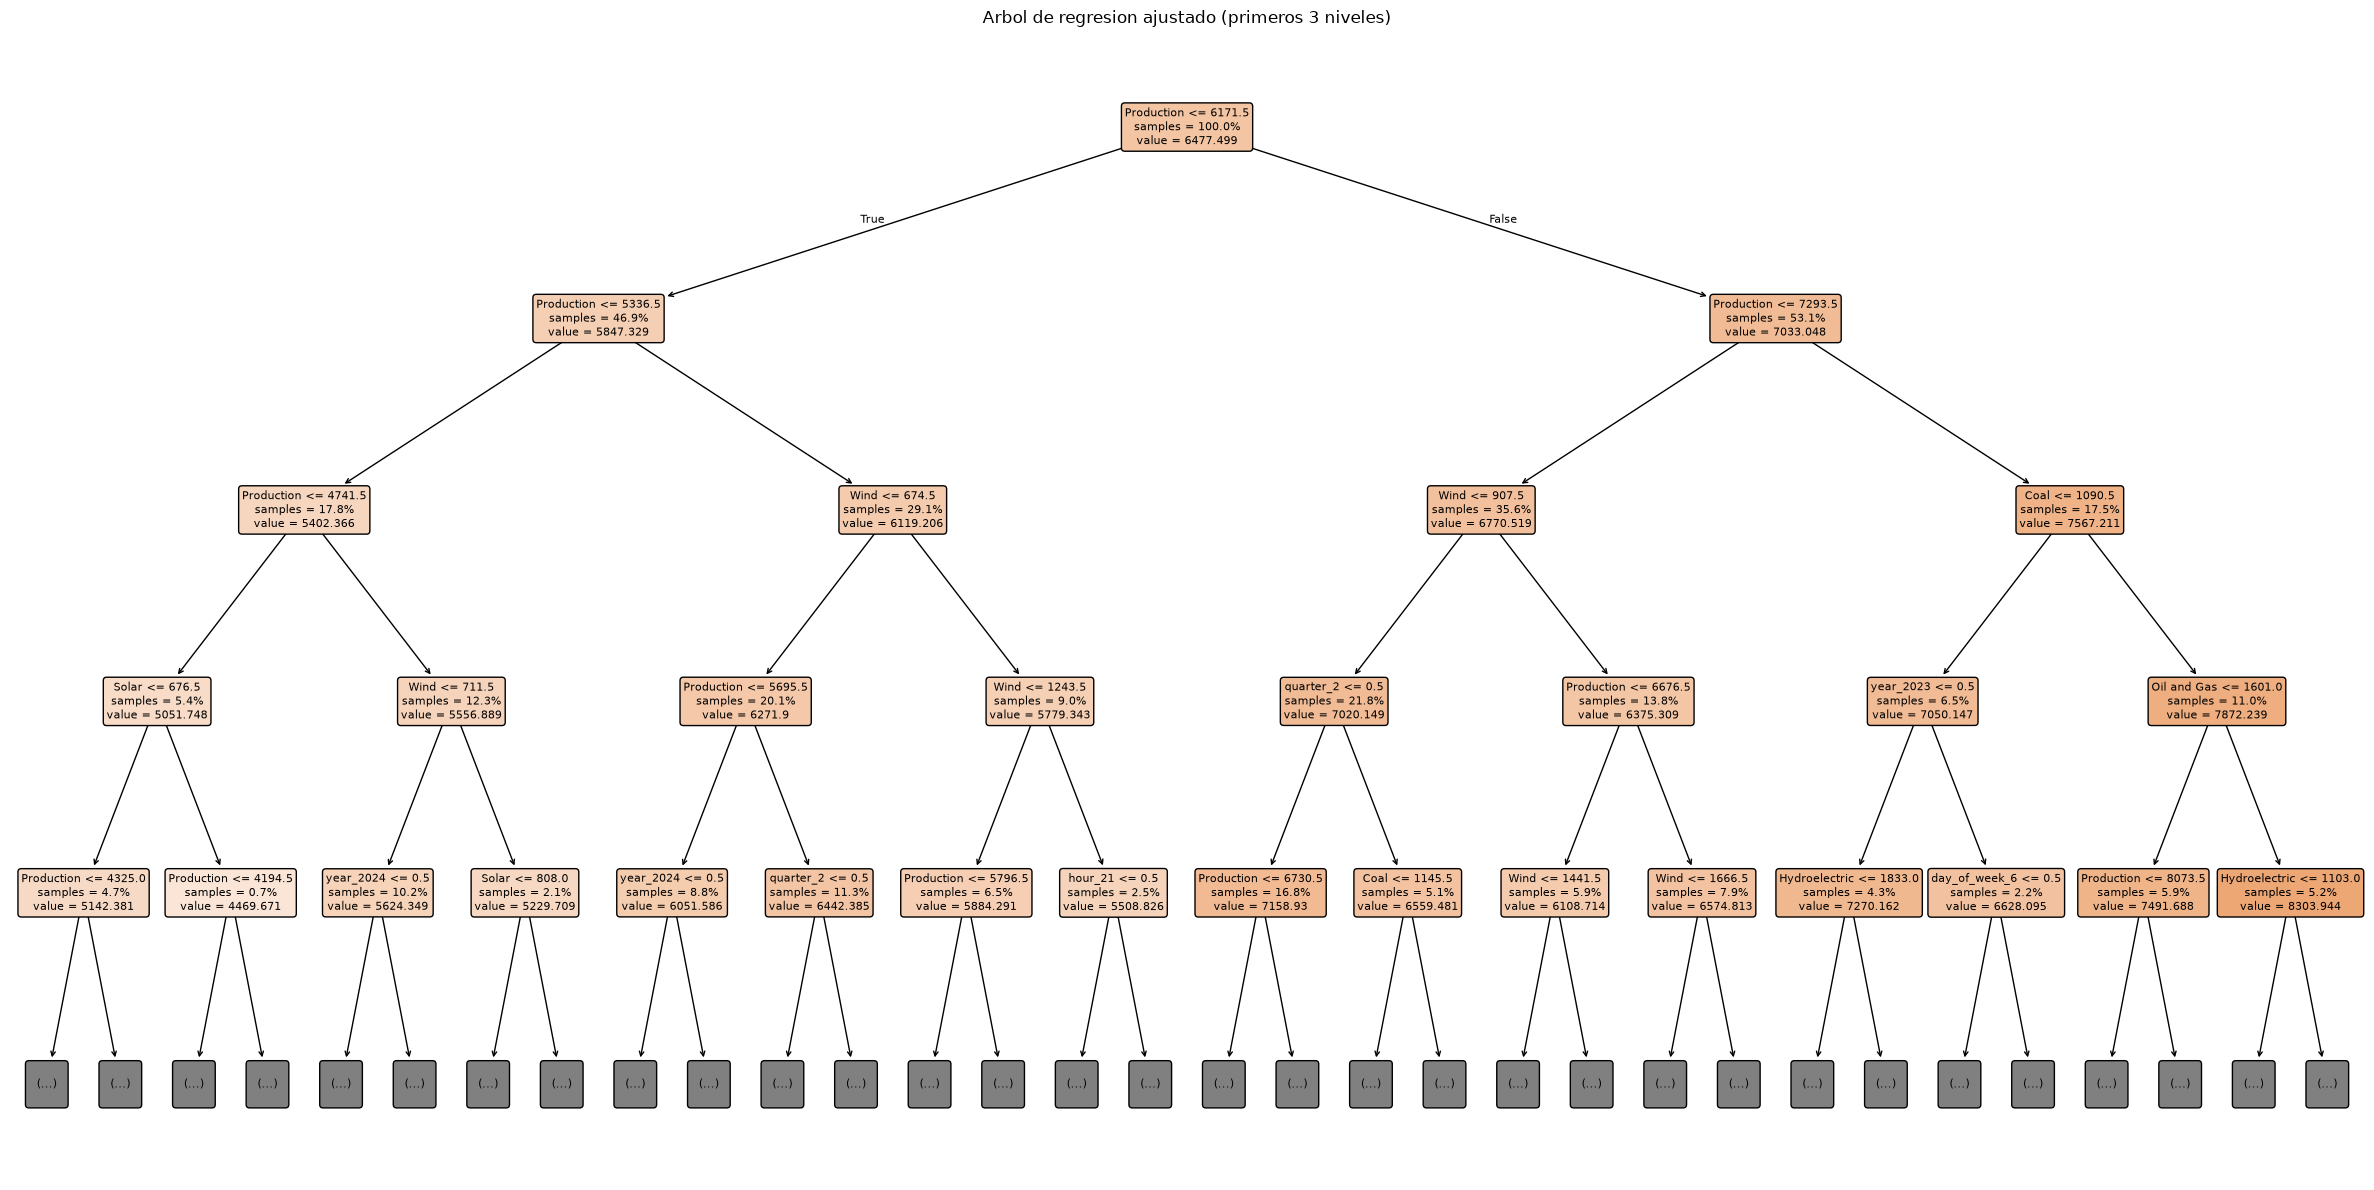

In [30]:
# Visualizacion de los primeros niveles del mejor arbol
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))
plot_tree(
    best_tree_model,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8,
    impurity=False,
    proportion=True,
)
plt.title('Arbol de regresion ajustado (primeros 3 niveles)')
plt.tight_layout()
plt.show()

## Conclusiones

Compara el error del árbol con DummyRegressor y revisa si las divisiones principales tienen sentido para las variables disponibles. Relaciona profundidad y tamaño de hojas con la complejidad observada. La importancia basada en impurity describe cómo el árbol utilizó los predictores en este ajuste; no es efecto causal ni una garantía de estabilidad.

## Ejercicios propuestos

1. **Conceptual:** explica por qué un árbol no necesita escalado y por qué aun así puede sobreajustar.
2. **Implementación:** cambia `max_depth` y `min_samples_leaf`, registra el número de hojas y compara errores.
3. **Experimentación:** contrasta la selección por `TimeSeriesSplit` con un único corte temporal de validation.
4. **Análisis:** compara la importancia de variables con el desempeño del baseline y comenta sus limitaciones.
5. **Desafío:** define cómo cambiaría la evaluación si se necesitara pronosticar un horizonte de 24 horas.

## Referencias

- [Árboles de decisión en scikit-learn](https://scikit-learn.org/stable/modules/tree.html)
- [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)
- La procedencia primaria y licencia del CSV eléctrico están pendientes de verificación; consulta [data/README.md](../../data/README.md).